# 📘 Week 1 Assignment — ML Foundations

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


## Part 1 — Python Fundamentals
### 1.1 Data Types & Control Flow

In [30]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

In [31]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

word_count = {}
for w in words:
    word_count[w] = word_count.get(w, 0) + 1

unique_words = set(words)

long_words = [w for w in words if len(w) > 5]

assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

In [32]:
def safe_divide(a, b):
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None

assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

In [33]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


## Part 2 — NumPy
### 2.1 Array Creation & Shapes

In [34]:
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

In [35]:
row2 = arr2d[1, :]
col3 = arr2d[:, 2]
sub  = arr2d[1:, 2:]
gt7  = arr2d[arr2d > 7]

assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7)  == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

In [36]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = A * B
D  = A @ B
dp = np.dot(np.array([1,2,3]), np.array([4,5,6]))
E  = A * 3

assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


## Part 3 — Pandas

In [37]:
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

In [38]:
salary_series = df['salary']
name_dept_df  = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [39]:
iloc_result = df.iloc[2:5, 0:3]
loc_result  = df.loc[[5, 6], ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

In [40]:
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]

dept_stats = (df.groupby('department')
               .agg(mean_salary=('salary','mean'), mean_performance=('performance','mean'))
               .sort_values('mean_salary', ascending=False)
               .round(2))

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,mean_salary,mean_performance
department,,
Engineering,92200.00,4.40
Marketing,71666.67,3.77
HR,61000.00,3.50


### 3.4 Handling Missing Data

In [41]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].median())
df_filled['age']    = df_filled['age'].fillna(round(df_filled['age'].mean()))
df_filled = df_filled.dropna(subset=['performance']).reset_index(drop=True)

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


## Part 4 — Linear Algebra
### 4.1 Vectors & Matrices as Data

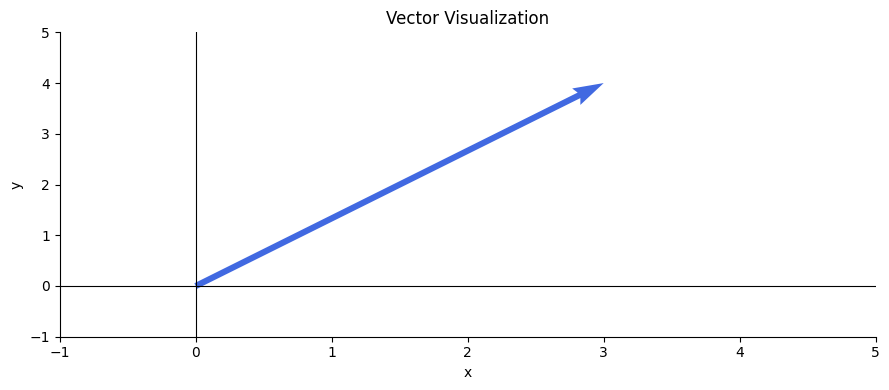

4.1 passed ✓  |v| = 5.0


In [42]:
v = np.array([3, 4])
norm_v = np.linalg.norm(v)
M = np.array([[1,2,3],[4,5,6],[7,8,9]])

fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='royalblue')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [43]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q
scalar3P = 3 * P
PQ       = P @ Q
QP       = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")
assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]
λ=5.0: Av=[3.53553391 3.53553391], λv=[3.53553391 3.53553391], match=True
λ=2.0: Av=[-0.89442719  1.78885438], λv=[-0.89442719  1.78885438], match=True


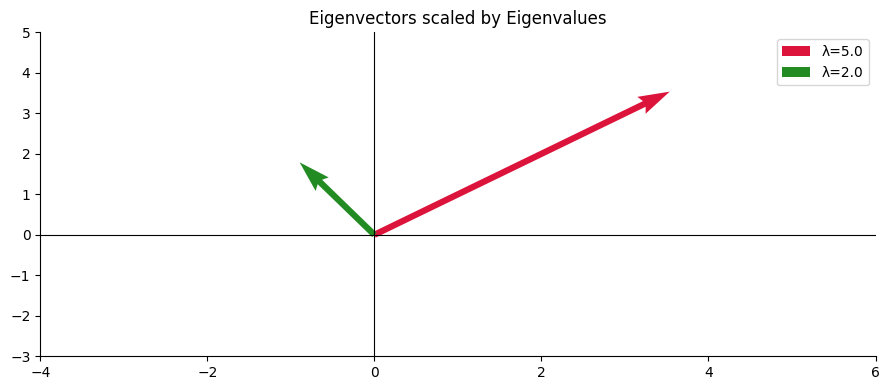

4.3 passed ✓


In [44]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

for i in range(len(eigenvalues)):
    lam, v = eigenvalues[i], eigenvectors[:, i]
    print(f"λ={lam:.1f}: Av={A@v}, λv={lam*v}, match={np.allclose(A@v, lam*v)}")

fig, ax = plt.subplots()
colors = ['crimson', 'forestgreen']
for i in range(2):
    v = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=colors[i], label=f'λ={eigenvalues[i]:.1f}')
ax.set_xlim(-4, 6); ax.set_ylim(-3, 5)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.set_title('Eigenvectors scaled by Eigenvalues')
ax.legend(); plt.tight_layout(); plt.show()
print("4.3 passed ✓")

### Geometric Explanation (4.3)
An eigenvector is a special vector that, when transformed by matrix A, only gets scaled — it does not change direction. The eigenvalue λ tells us how much it is scaled. If λ > 1 the vector stretches, if 0 < λ < 1 it shrinks, and if λ < 0 it flips direction.

### 4.4 SVD & Dimensionality Reduction

In [45]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
X_reconstructed = U @ np.diag(S) @ Vt
X_approx        = S[0] * np.outer(U[:, 0], Vt[0, :])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx.round(4)}")
assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 1.30e-15
Rank-1 approximation:
[[ 0.3162  0.0381 -0.0701]
 [ 1.4541  0.1753 -0.3226]
 [ 1.6695  0.2012 -0.3703]
 [ 0.5547  0.0669 -0.123 ]]
4.4 passed ✓


### SVD → PCA Connection (4.4)
- **U** — left singular vectors (sample space directions)
- **S** — singular values (amount of variance captured)
- **Vt** — right singular vectors = **principal component directions** (directions of max variance)

When data is mean-centered, SVD on X gives the same result as PCA. The rows of Vt are principal components and S² / (n-1) gives the variance explained by each component.

## Part 5 — Statistics
### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


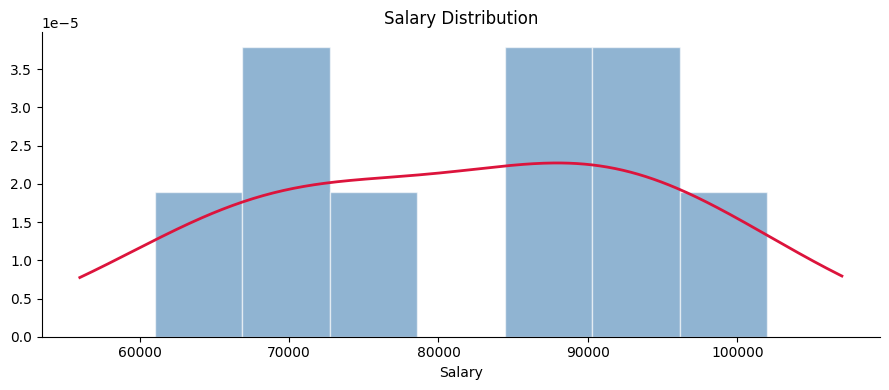

In [46]:
salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

fig, ax = plt.subplots()
ax.hist(salary, bins=7, density=True, alpha=0.6, color='steelblue', edgecolor='white')
xs = np.linspace(salary.min()-5000, salary.max()+5000, 300)
ax.plot(xs, stats.gaussian_kde(salary)(xs), color='crimson', lw=2)
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

### Definitions (5.1)
**Population:** The complete set of all individuals or observations of interest.
**Sample:** A subset drawn from the population used to make inferences.
**Descriptive statistic:** A summary measure that describes the collected data (e.g., mean, std).
**Inferential statistic:** A method that uses sample data to draw conclusions about the population (e.g., t-test).

### 5.2 Hypothesis Testing

In [47]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

t_stat, p_value = stats.ttest_1samp(eng_salaries, overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


### H₀ / H₁ and Interpretation (5.2)
**H₀:** Engineering mean salary = overall mean salary.
**H₁:** Engineering mean salary ≠ overall mean salary.
**Conclusion:** If p < 0.05 we reject H₀ and conclude Engineering salaries are significantly different from the company average. The Pearson r shows the strength of linear relationship between salary and experience.

### 5.3 Error Metrics

In [48]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae    = np.mean(np.abs(y_true - y_pred))
mse    = np.mean((y_true - y_pred) ** 2)
rmse   = np.sqrt(mse)
r2     = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:     {mae:.4f}")
print(f"MSE:     {mse:.4f}")
print(f"RMSE:    {rmse:.4f}")
print(f"R²:      {r2:.4f}")
print(f"Adj. R²: {adj_r2:.4f}")

MAE:     0.3500
MSE:     0.1400
RMSE:    0.3742
R²:      0.9689
Adj. R²: 0.9564


### 5.4 Distribution Testing & Stationarity

In [49]:

import sys
!{sys.executable} -m pip install statsmodels
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

ks_s1 = stats.kstest(s1, 'norm', args=(0, 1))
ks_s2 = stats.kstest(s2, 'norm', args=(0, 1))
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

t  = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

ts_diff  = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

PSI: 2.0611
Shift severity: Major


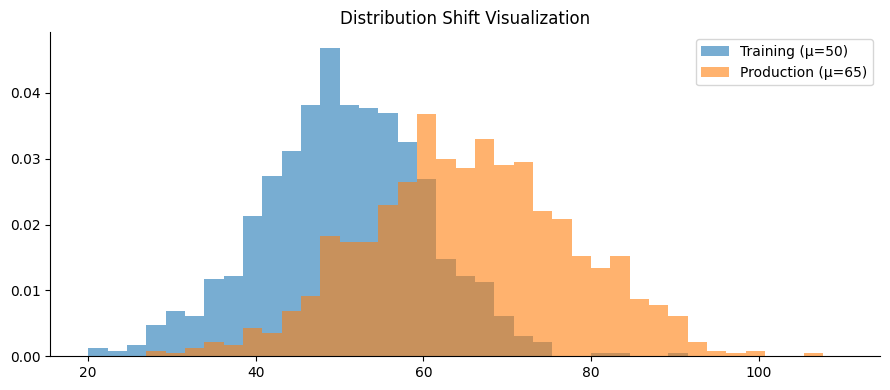

In [50]:
def compute_psi(expected, actual, bins=10):
    eps = 1e-10
    bp  = np.linspace(expected.min(), expected.max(), bins + 1)
    ec, _ = np.histogram(expected, bins=bp)
    ac, _ = np.histogram(actual,   bins=bp)
    ep = ec / len(expected) + eps
    ap = ac / len(actual)   + eps
    return np.sum((ap - ep) * np.log(ap / ep))

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)
drift_dist = np.random.normal(65, 12, 1000)

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

fig, ax = plt.subplots()
b = np.linspace(20, 110, 40)
ax.hist(train_dist, bins=b, alpha=0.6, density=True, label='Training (μ=50)')
ax.hist(drift_dist, bins=b, alpha=0.6, density=True, label='Production (μ=65)')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

### Concept Drift vs Covariate Drift & PSI Thresholds (5.5)
**Concept drift:** P(y|X) changes — the relationship between features and target shifts over time.
**Covariate drift:** P(X) changes — input feature distribution shifts, but P(y|X) may remain the same.
**PSI < 0.1:** No significant shift — model is stable.
**PSI 0.1–0.2:** Minor shift — monitor closely.
**PSI > 0.2:** Major shift — retrain the model.
**Retraining trigger example:** Trigger retraining when PSI > 0.2 on any key feature in the weekly monitoring run.

## Part 6 — Probability Theory
### 6.1 Core Concepts

In [51]:
total = 10
red, blue, green = 4, 3, 3

p_red   = red   / total
p_blue  = blue  / total
p_green = green / total

p_red_then_blue  = (red / total) * (blue / (total - 1))
p_blue_given_red = blue / (total - 1)
independent      = np.isclose(p_blue_given_red, p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

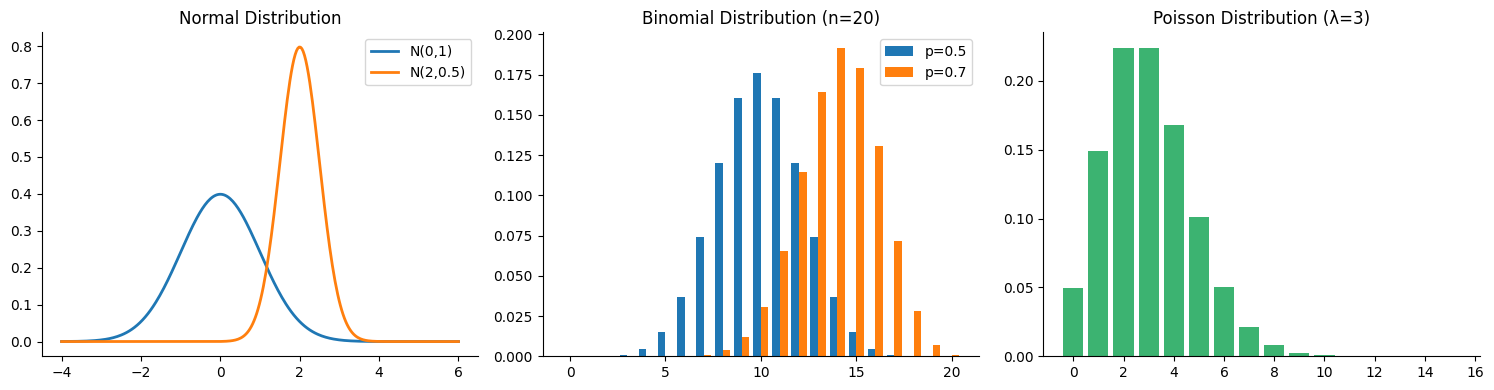

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-4, 6, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, 1),   lw=2, label='N(0,1)')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), lw=2, label='N(2,0.5)')
axes[0].set_title('Normal Distribution'); axes[0].legend()

k = np.arange(0, 21)
axes[1].bar(k - 0.2, stats.binom.pmf(k, 20, 0.5), width=0.4, label='p=0.5')
axes[1].bar(k + 0.2, stats.binom.pmf(k, 20, 0.7), width=0.4, label='p=0.7')
axes[1].set_title('Binomial Distribution (n=20)'); axes[1].legend()

k2 = np.arange(0, 16)
axes[2].bar(k2, stats.poisson.pmf(k2, 3), color='mediumseagreen')
axes[2].set_title('Poisson Distribution (λ=3)')

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

In [53]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

p_free            = p_free_given_spam * p_spam + p_free_given_ham * p_ham
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    p_word = p_word_given_spam * prior_spam + p_word_given_ham * (1 - prior_spam)
    return (p_word_given_spam * prior_spam) / p_word

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


### Bayes Term Mapping (6.3)

| Term | Formula | In this example |
|---|---|---|
| Prior | P(Spam) | 0.30 — baseline chance any email is spam |
| Likelihood | P(word\|Spam) | 0.80 — how often "free" appears in spam |
| Evidence | P(word) | 0.275 — overall chance of seeing "free" |
| Posterior | P(Spam\|word) | ≈ 0.8727 — updated probability after seeing "free" |

### 6.4 Central Limit Theorem

Population mean: 1.0005, std: 1.0006
Sample means — mean: 1.0021, std: 0.1845
CLT predicted std: 0.1827


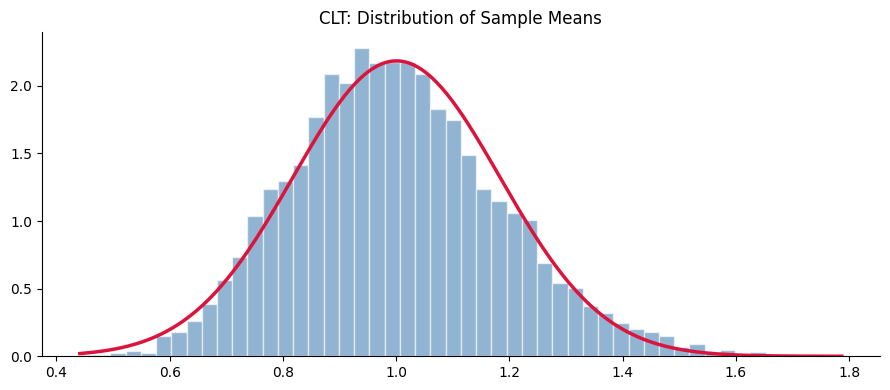

KS test p-value: 0.0054 → Approximately normal? False


In [54]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

sample_means = np.array([np.random.choice(population, 30, replace=False).mean()
                         for _ in range(5000)])

pop_mean = population.mean()
pop_std  = population.std()
clt_std  = pop_std / np.sqrt(30)

print(f"Population mean: {pop_mean:.4f}, std: {pop_std:.4f}")
print(f"Sample means — mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

fig, ax = plt.subplots()
ax.hist(sample_means, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
xs = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, pop_mean, clt_std), color='crimson', lw=2.5)
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout(); plt.show()

ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

### CLT Reflection (6.4)
The CLT states that sample means from any population distribution will be approximately normally distributed when the sample size is large enough (n ≥ 30). This matters because most classical statistical tests (t-test, z-test) assume normality of the estimator — the CLT is what makes that assumption valid even when the underlying data is not normal.

## 🏁 Submission Checklist
- [x] All assert blocks pass
- [x] All code cells filled
- [x] All markdown cells filled
- [x] All plots have labels and titles
- [x] Notebook runs top to bottom